## **Data Analysis of Blinkit by python**

### **Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **Import Raw data**

In [2]:
df = pd.read_csv("C:/Users/Wolf/Downloads/Blinkit/blinkit_data.csv")

#### **Sample data**

In [3]:
df.head(2)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.1,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.8,115.3492,5.0


In [4]:
df.tail(2)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


#### **Size of data**

In [5]:
print("size of data", df.shape)

size of data (8523, 12)


#### **Columns**

In [6]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

#### **Data types**

In [7]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

## **Data Cleaning**

#### **Column cleaning Item Fat Content**

In [8]:
print(df["Item Fat Content"].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [9]:
df["Item Fat Content"] = df["Item Fat Content"].replace({'LF':'Low Fat', 'low fat' :'Low Fat','reg' :'Regular'})

In [10]:
print(df["Item Fat Content"].unique())

['Regular' 'Low Fat']


### **BUSINESS REQUIREMENTS**

##### TOTAL SALES
##### AVERAGE SALES
##### NUMBER OF ITEMS
##### AVERAGE RATING

#### **TOTAL SALES**

In [11]:
#Total Sales
total_sales = df['Sales'].sum()

#Average Sales
avg_sales = df['Sales'].mean()

# No. of items sold
items_sold = df['Sales'].count()

# Average Rating
avg_rating = df['Rating'].mean()


In [12]:
print(f"Total Sales: ${total_sales:,.1f}")
print(f"Average Sales: ${avg_sales:,.1f}")
print(f"Items Sold: {items_sold:,.0f}")
print(f"Average Rating: {avg_rating:,.1f}")

Total Sales: $1,201,681.5
Average Sales: $141.0
Items Sold: 8,523
Average Rating: 4.0


## Chart Requirements

### **Total sales by fat content**

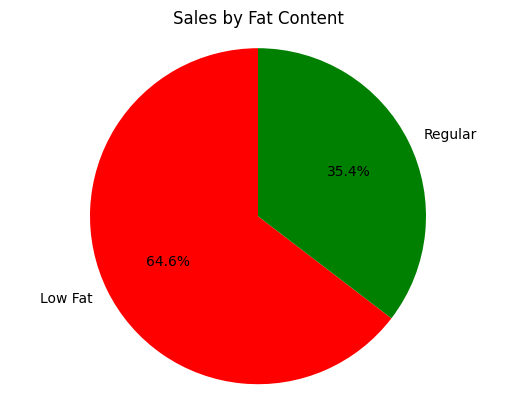

In [13]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()
plt.pie(sales_by_fat, labels= sales_by_fat.index,
        autopct = '%.1f%%',
        startangle = 90,colors=('red','green'))
plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()
          

### **Total sales by Item Types**

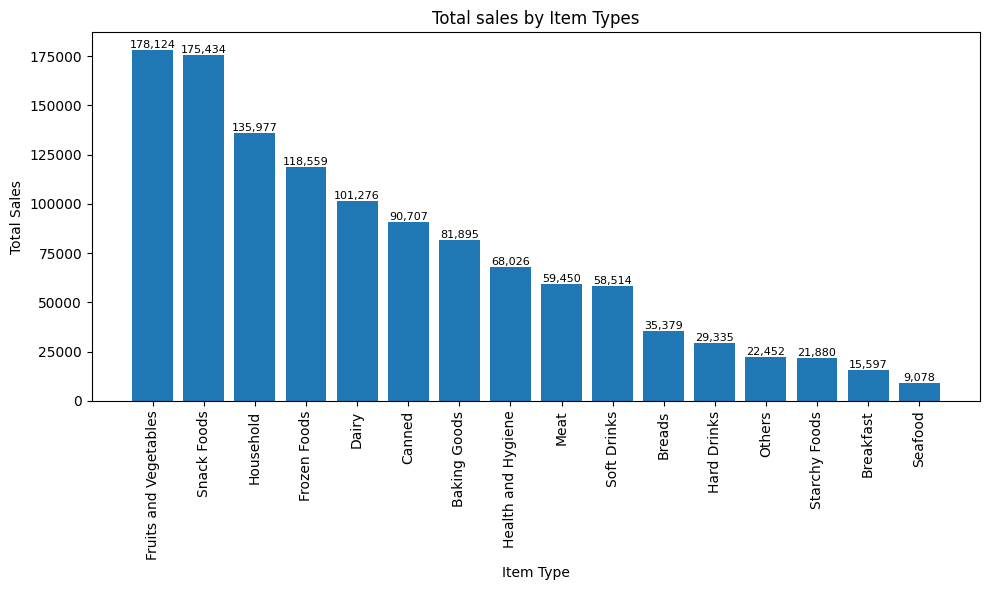

In [20]:
sales_by_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending= False)
plt.figure(figsize = (10,6))
bars = plt.bar(sales_by_type.index, sales_by_type.values)
plt.xticks(rotation = 90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total sales by Item Types')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():,.0f}', ha= 'center',va = 'bottom',fontsize = 8)
plt.tight_layout()
plt.show()

### Fat Content

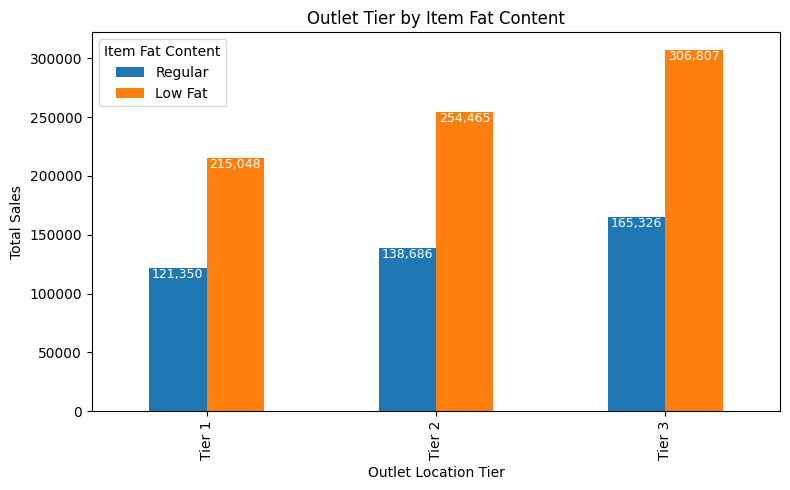

In [46]:
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular','Low Fat']]

ax = grouped.plot(kind = 'bar', figsize = (8,5), title = 'Outlet Tier by Item Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title = 'Item Fat Content')

for p in ax.patches:
    height = p.get_height()
    if height >0:
        ax.annotate(f'{height:,.0f}',
            (p.get_x() + p.get_width() / 2, height),
            ha='center', va='top', fontsize=9, color='white')
    
plt.tight_layout()
plt.show()

### Outlet Establishment

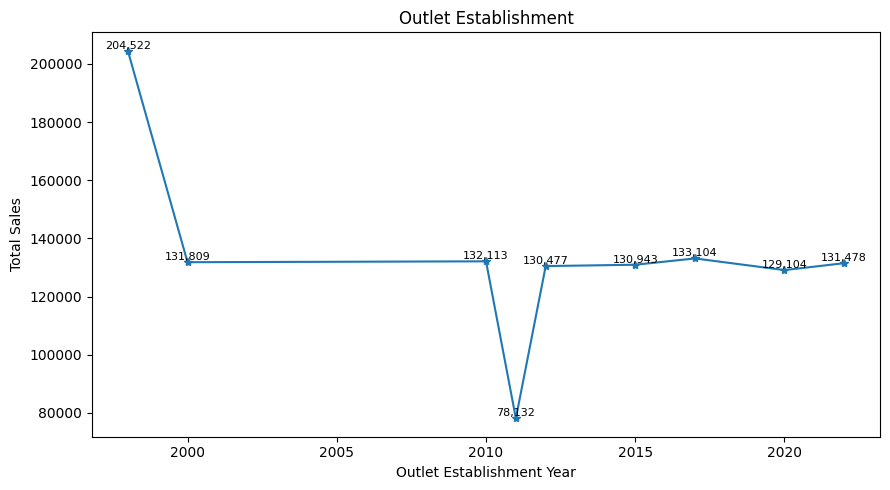

In [50]:
sales_by_years = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()
plt.figure(figsize =(9,5))
plt.plot(sales_by_years.index, sales_by_years.values, marker = '*', linestyle = '-')

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

for x, y in zip(sales_by_years.index, sales_by_years.values):
    plt.text(x,y, f'{y:,.0f}', ha = 'center', va = 'bottom', fontsize = 8)

plt.tight_layout()
plt.show()

### Sales by outlet size

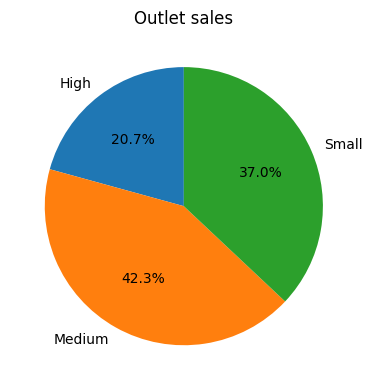

In [55]:
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize = (4,4))
plt.pie(sales_by_size, labels= sales_by_size.index, autopct='%1.1f%%', startangle= 90)
plt.title('Outlet sales')
plt.tight_layout()
plt.show()